## Initial Imports 
Import PLAMS components and set up to run jobs in tandem.

In [4]:
from scm.plams import Settings, AMSJob, Molecule, Atom, FCFJob, config, JobRunner, init
from scm.plams.recipes.fcf_dos import FCFDOS
import matplotlib.pyplot as plt

try:
    from scm.plams import view  # view molecule using AMSview in a Jupyter Notebook in AMS2026+

    _has_view = True
except ImpoGrtError:
    from scm.plams import plot_molecule  # plot molecule in a Jupyter Notebook in AMS2023+

    _has_view = False

    def view(molecule, ax=None, **kwargs):
        plot_molecule(molecule, ax=ax)

In [5]:
config.default_jobrunner.parallel = JobRunner(parallel=True, maxjobs=2)

# this line is not required in AMS2025+
init()

## Setup Molecules
Create the NO<sub>2</sub> molecules using pre-optimized geometries (usually the geometry optimization step would come first).

In [8]:
no2_radical = Molecule()
no2_radical.add_atom(Atom(atnum=7, coords=(0.0, 0.0, -0.01857566)))
no2_radical.add_atom(Atom(atnum=8, coords=(0.0, 1.09915770, -0.49171967)))
no2_radical.add_atom(Atom(atnum=8, coords=(0.0, -1.09915770, -0.49171967)))
no2_radical.guess_bonds()

no2_anion = Molecule()
no2_anion.add_atom(Atom(atnum=7, coords=(0.0, 0.0, 0.12041)))
no2_anion.add_atom(Atom(atnum=8, coords=(0.0, 1.070642, -0.555172)))
no2_anion.add_atom(Atom(atnum=8, coords=(0.0, -1.070642, -0.555172)))
no2_anion.guess_bonds()

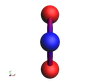

In [15]:
view(no2_radical, height=100, width=100)

## Calculate Vibrational Frequencies
Create the settings objects for the ADF donor/acceptor vibrational frequencies calculations. Run the calculations in parallel.

In [16]:
settings_freq = Settings()
settings_freq.input.adf.symmetry = "NoSym"
settings_freq.input.adf.basis.type = "DZP"
settings_freq.input.adf.basis.core = "None"
settings_freq.input.adf.xc.lda = "SCF VWN"
settings_freq.input.ams.Task = "SinglePoint"
settings_freq.input.ams.Properties.NormalModes = "Yes"
settings_freq.input.adf.title = "Vibrational frequencies"

settings_freq_radical = settings_freq.copy()
settings_freq_radical.input.ams.system.charge = 0
settings_freq_radical.input.adf.spinpolarization = 1
settings_freq_radical.input.adf.unrestricted = "Yes"

settings_freq_anion = settings_freq.copy()
settings_freq_anion.input.ams.system.charge = -1

In [17]:
freq_job_radical = AMSJob(molecule=no2_radical, settings=settings_freq_radical, name="fsradical")
freq_job_anion = AMSJob(molecule=no2_anion, settings=settings_freq_anion, name="fsanion")

freq_results = (freq_job_radical.run(), freq_job_anion.run())

[26.03|17:44:04] JOB fsradical STARTED
[26.03|17:44:04] JOB fsanion STARTED
[26.03|17:44:04] JOB fsradical RUNNING
[26.03|17:44:04] JOB fsanion RUNNING
[26.03|17:44:12] JOB fsanion FINISHED
[26.03|17:44:12] JOB fsanion SUCCESSFUL
[26.03|17:44:13] JOB fsradical FINISHED
[26.03|17:44:13] JOB fsradical SUCCESSFUL


We can view the resulting vibrational modes in amsspectra

In [28]:
rkf = freq_results[0].rkfpath(file="adf")
!amsspectra {rkf}

## Calculate Vibronic Spectra
Use Frank-Condon jobs to calculate the vibronic spectra.

In [29]:
def fcf_job(state1, state2, spctype, name):
    settings_fcf = Settings()
    settings_fcf.input.spectrum.type = spctype
    settings_fcf.input.state1 = state1
    settings_fcf.input.state2 = state2
    return FCFJob(inputjob1=state1, inputjob2=state2, settings=settings_fcf, name=name)


freq_radical = freq_results[0].rkfpath(file="adf")
freq_anion = freq_results[1].rkfpath(file="adf")

fc_abs = fcf_job(freq_radical, freq_anion, "absorption", "fcfabs")
fc_emi = fcf_job(freq_anion, freq_radical, "emission", "fcfemi")

fc_results = (fc_abs.run(), fc_emi.run())

[30.03|10:07:58] JOB fcfabs STARTED
[30.03|10:07:58] JOB fcfemi STARTED
[30.03|10:07:58] JOB fcfabs RUNNING
[30.03|10:07:58] JOB fcfemi RUNNING
[30.03|10:08:00] JOB fcfemi FINISHED
[30.03|10:08:00] JOB fcfemi SUCCESSFUL
[30.03|10:08:00] JOB fcfabs FINISHED
[30.03|10:08:00] JOB fcfabs SUCCESSFUL


## Calculate Density of States

Calculate the DOS by computing the overlap of the absorption and emission FCF spectra.

In [30]:
job = FCFDOS(fc_results[0].kfpath(), fc_results[1].kfpath(), 10000.0, 10000.0)
dos = job.dos()

In [31]:
print(f"The density of states is {dos:.8e}")

The density of states is 1.30090295e-08
